REGIONES Y FRONTERAS 

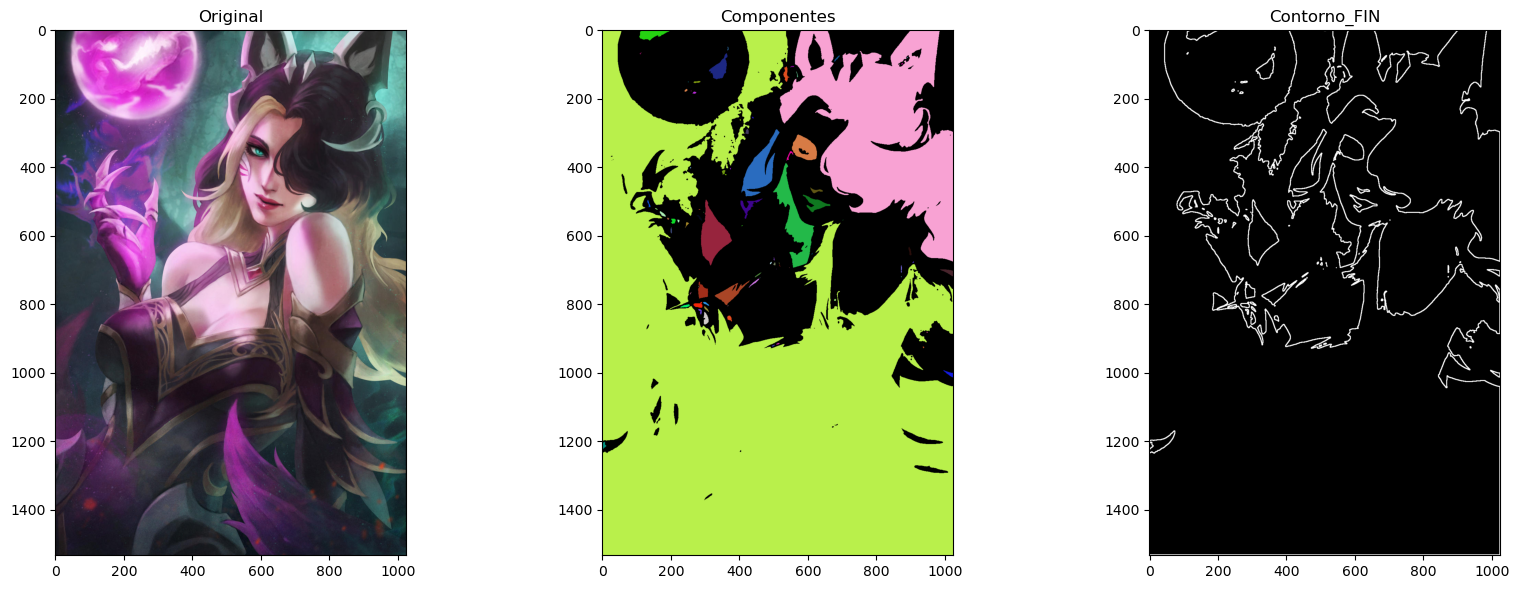

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('AHRI.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (7, 7), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
num_l, label = cv2.connectedComponents(binary)

color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
color[0] = [0, 0, 0] 
colorear = color[label]
contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(20, 15))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(2, 3, 2)
plt.imshow(colorear)
plt.title("Componentes")

plt.subplot(2, 3, 3)
plt.imshow(contorno_fin,cmap='gray')
plt.title("Contorno_FIN")

plt.show()

CONTEO

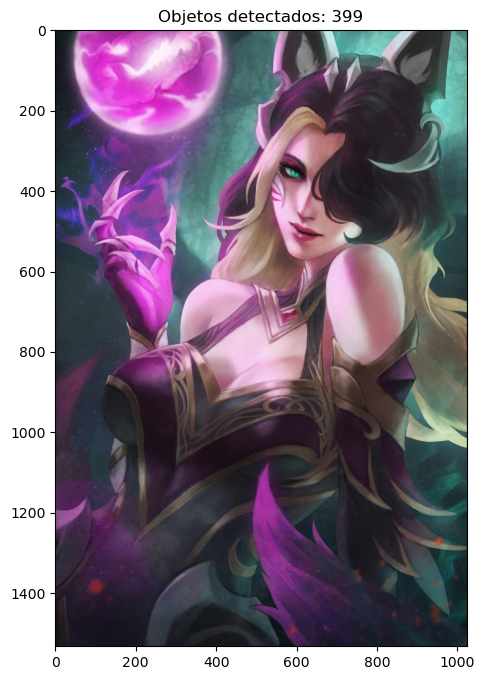

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    e_img = measure.label(binary, connectivity=2)  # conectividad 8
    num_obj = np.max(e_img)
    return num_obj

# Cargar imagen
imagen = cv2.imread('ahri.jpg')

# Contar elementos
num = contar_elementos(imagen)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title(f"Objetos detectados: {num}")
plt.show()

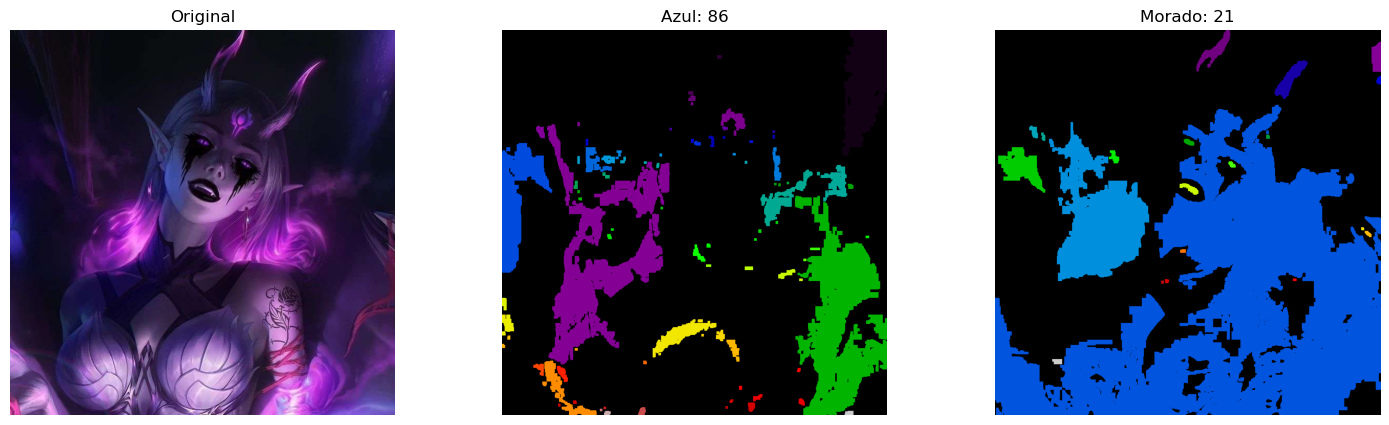

=== Resumen ===
Azul : 86
Morado : 21


In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def analizar_imagen(ruta):
    img = cv2.imread(ruta)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    colores = {
        'Rojo': ([0,100,100], [10,255,255]),
        'Azul': ([100,150,50], [140,255,255]),
        'Verde': ([35,100,50], [85,255,255]),
        'Amarillo': ([20,100,100], [32,255,255]),
        'Morado': ([130,50,50], [160,255,255]),
        'Naranja': ([11,100,100], [25,255,255])
    }

    resultados = {}

    for nombre, (bajo, alto) in colores.items():
        mask = cv2.inRange(hsv, np.array(bajo), np.array(alto))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))

        labels = measure.label(mask, connectivity=2)
        cantidad = labels.max()

        if cantidad > 0:
            resultados[nombre] = (labels, cantidad)

    # Mostrar resultados
    n = len(resultados) + 1
    fig, ax = plt.subplots(1, n, figsize=(18,5))

    ax[0].imshow(rgb)
    ax[0].set_title("Original")
    ax[0].axis("off")

    i = 1
    for nombre, (labels, cantidad) in resultados.items():
        ax[i].imshow(labels, cmap="nipy_spectral")
        ax[i].set_title(f"{nombre}: {cantidad}")
        ax[i].axis("off")
        i += 1

    plt.show()

    print("=== Resumen ===")
    for nombre, (_, cantidad) in resultados.items():
        print(nombre, ":", cantidad)

analizar_imagen("ov.jpg")